In [ ]:
# Cell 0: Clone the GitHub repo and stage CSVs at /content/
import os
GITHUB_USERNAME = "AlvinJames00"
REPO_NAME = "Hackathon"
BRANCH = "main"
REPO_URL = f"https://github.com/{GITHUB_USERNAME}/{REPO_NAME}.git"
REPO_DIR = f"/content/{REPO_NAME}"

if os.path.exists(REPO_DIR):
    %cd $REPO_DIR
    !git pull origin $BRANCH
else:
    !git clone $REPO_URL $REPO_DIR
    %cd $REPO_DIR

!cp {REPO_DIR}/dataset_Repeat_training.csv /content/ 2>/dev/null || true
!cp {REPO_DIR}/dataset_Repeat_testing.csv /content/ 2>/dev/null || true
print("Repo cloned, CSVs in /content/")


<a href="https://colab.research.google.com/github/AlvinJames00/Hackathon/blob/main/23111190.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q xgboost shap

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)

from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded.")

Libraries loaded.


In [3]:
def find_file(filename):
    candidates = [
        filename,
        f"/content/{filename}",
        f"/mnt/data/{filename}"
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(f"{filename} not found. Upload it to Colab.")

train = pd.read_csv(find_file("dataset_Repeat_training.csv"))
test = pd.read_csv(find_file("dataset_Repeat_testing.csv"))

TARGET = "Transported"
ID = "PassengerId"

print("train:", train.shape, "| test:", test.shape)
display(train.head())

train: (5798, 14) | test: (2895, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,2010_01,Earth,True,G/324/P,PSO J318.5-22,33.0,False,0.0,0.0,0.0,0.0,NaN,Candyn Gregordy,True
1,3117_01,Earth,False,F/646/P,TRAPPIST-1e,32.0,False,0.0,0.0,47.0,857.0,23.0,NaN,False
2,5848_01,Earth,False,E/377/S,NaN,28.0,False,229.0,761.0,0.0,0.0,6.0,Eriana Benney,True
3,7785_01,Earth,False,G/1261/S,TRAPPIST-1e,13.0,False,406.0,0.0,52.0,0.0,387.0,Luise Bucklandez,False
4,8375_01,Earth,False,NaN,PSO J318.5-22,15.0,False,64.0,0.0,0.0,0.0,640.0,Carlen Valezaley,True


In [4]:
print("TRAIN INFO")
train.info()

print("\nTEST INFO")
test.info()

print("\nDuplicate rows in train:", train.duplicated().sum())
print("Duplicate rows in test :", test.duplicated().sum())
print("Duplicate PassengerIds in train:", train[ID].duplicated().sum())
print("Duplicate PassengerIds in test :", test[ID].duplicated().sum())

display(train.describe(include="all").T)

TRAIN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5798 entries, 0 to 5797
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   5798 non-null   object 
 1   HomePlanet    5660 non-null   object 
 2   CryoSleep     5657 non-null   object 
 3   Cabin         5663 non-null   object 
 4   Destination   5676 non-null   object 
 5   Age           5678 non-null   float64
 6   VIP           5660 non-null   object 
 7   RoomService   5679 non-null   float64
 8   FoodCourt     5682 non-null   float64
 9   ShoppingMall  5668 non-null   float64
 10  Spa           5675 non-null   float64
 11  VRDeck        5665 non-null   float64
 12  Name          5655 non-null   object 
 13  Transported   5798 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 594.7+ KB

TEST INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2895 entries, 0 to 2894
Data columns (total 13 columns):
 #   Column  

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,5798,5798,1142_01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HomePlanet,5660,3,Earth,3079,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CryoSleep,5657,2,False,3633,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cabin,5663,4659,C/21/P,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Destination,5676,3,TRAPPIST-1e,3949,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,5678.0,NaN,NaN,NaN,28.877598,14.561429,0.0,19.0,27.0,38.0,78.0
VIP,5660,2,False,5523,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RoomService,5679.0,NaN,NaN,NaN,218.186124,647.070964,0.0,0.0,0.0,42.0,9920.0
FoodCourt,5682.0,NaN,NaN,NaN,455.892819,1606.591863,0.0,0.0,0.0,82.0,29813.0
ShoppingMall,5668.0,NaN,NaN,NaN,169.183663,616.175949,0.0,0.0,0.0,25.0,23492.0


,Count,Percent
Transported,,
True,2923,50.41
False,2875,49.59


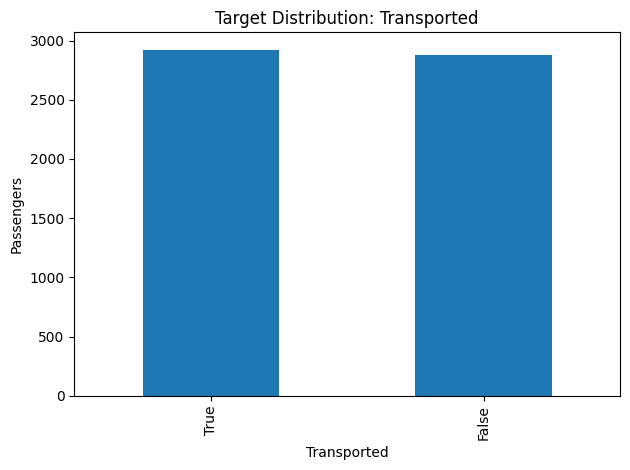

In [5]:
target_summary = pd.DataFrame({
    "Count": train[TARGET].value_counts(),
    "Percent": (train[TARGET].value_counts(normalize=True) * 100).round(2)
})
display(target_summary)

train[TARGET].value_counts().plot(kind="bar")
plt.title("Target Distribution: Transported")
plt.xlabel("Transported")
plt.ylabel("Passengers")
plt.tight_layout()
plt.show()

,Missing_Count,Missing_Percent
Name,143,2.47
CryoSleep,141,2.43
VIP,138,2.38
HomePlanet,138,2.38
Cabin,135,2.33
VRDeck,133,2.29
ShoppingMall,130,2.24
Spa,123,2.12
Destination,122,2.10
Age,120,2.07


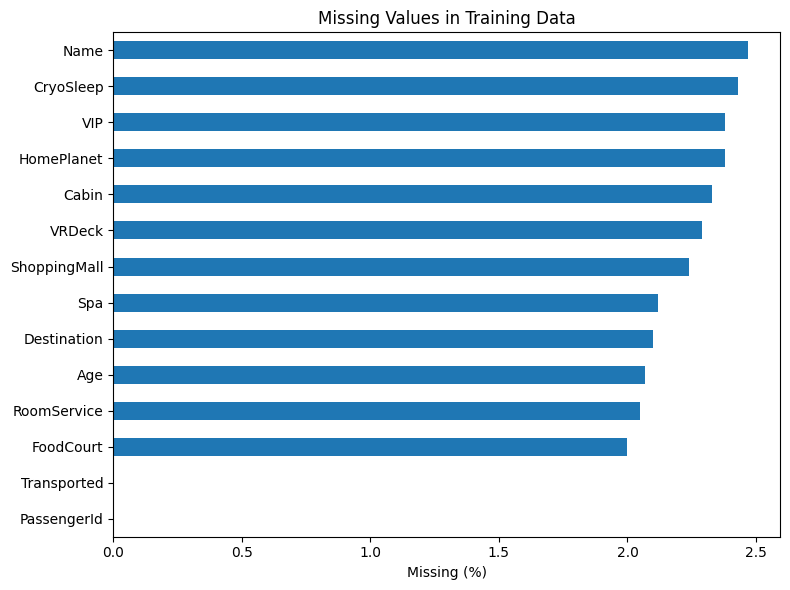

In [6]:
missing_summary = pd.DataFrame({
    "Missing_Count": train.isna().sum(),
    "Missing_Percent": (train.isna().mean() * 100).round(2)
}).sort_values("Missing_Percent", ascending=False)

display(missing_summary)

missing_summary["Missing_Percent"].sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Missing Values in Training Data")
plt.xlabel("Missing (%)")
plt.tight_layout()
plt.show()

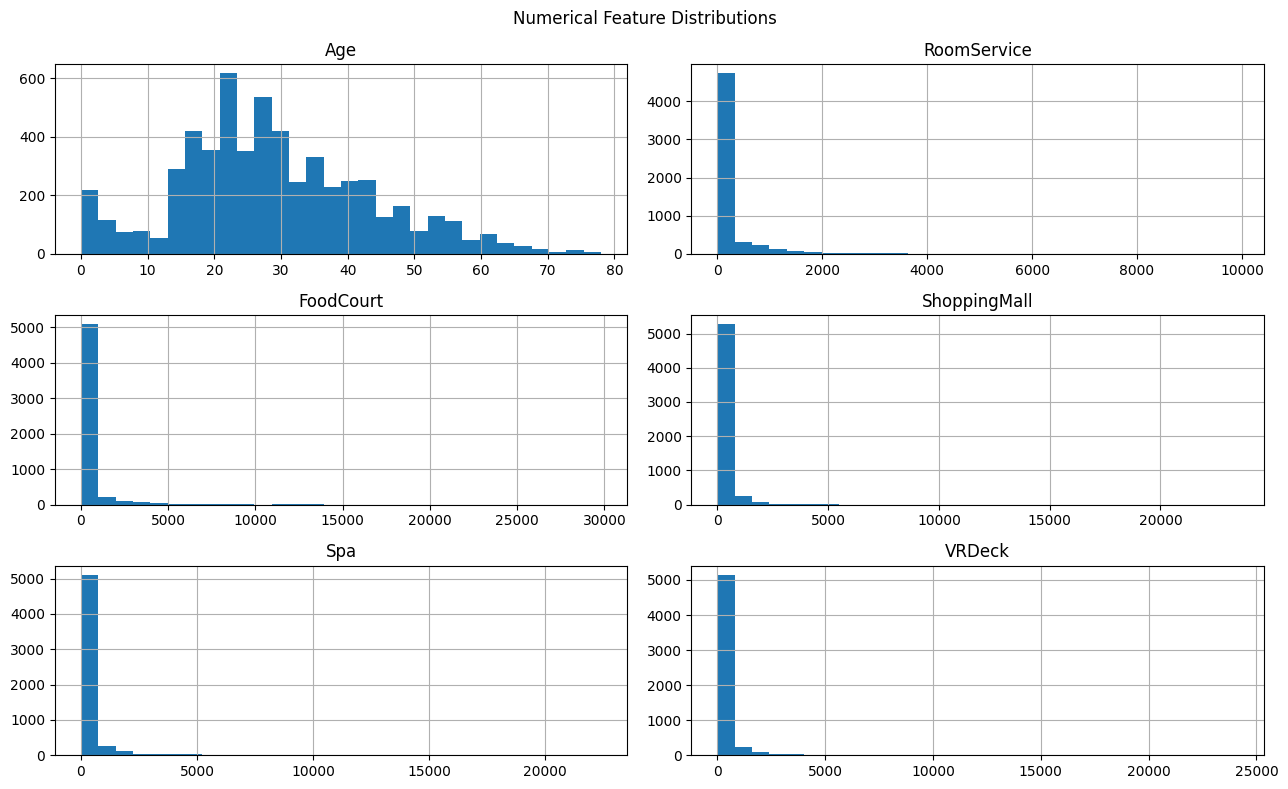

,count,Transport_Rate
NoSpend,,
False,3360,0.297024
True,2438,0.789582


In [7]:
numeric_cols_original = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

train[numeric_cols_original].hist(figsize=(13,8), bins=30)
plt.suptitle("Numerical Feature Distributions")
plt.tight_layout()
plt.show()

spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
eda_spend = train.copy()
eda_spend["TotalSpend"] = eda_spend[spend_cols].sum(axis=1, min_count=1)
eda_spend["NoSpend"] = (eda_spend[spend_cols].fillna(0).sum(axis=1) == 0)

display(
    eda_spend.groupby("NoSpend")[TARGET]
    .agg(["count", "mean"])
    .rename(columns={"mean":"Transport_Rate"})
)

In [8]:
for col in ["HomePlanet", "CryoSleep", "Destination", "VIP"]:
    print(f"\nTransport rate by {col}")
    display(
        train.groupby(col, dropna=False)[TARGET]
        .agg(["count","mean"])
        .rename(columns={"mean":"Transport_Rate"})
        .sort_values("Transport_Rate", ascending=False)
    )


Transport rate by HomePlanet


,count,Transport_Rate
HomePlanet,,
Europa,1439,0.653926
Mars,1142,0.550788
NaN,138,0.492754
Earth,3079,0.417343



Transport rate by CryoSleep


,count,Transport_Rate
CryoSleep,,
True,2024,0.819664
NaN,141,0.517730
False,3633,0.327828



Transport rate by Destination


,count,Transport_Rate
Destination,,
55 Cancri e,1206,0.601990
PSO J318.5-22,521,0.508637
NaN,122,0.475410
TRAPPIST-1e,3949,0.474551



Transport rate by VIP


,count,Transport_Rate
VIP,,
NaN,138,0.514493
False,5523,0.507333
True,137,0.364964


In [9]:
temp = train.copy()

# Cabin components
cabin = (
    temp["Cabin"]
    .fillna("Unknown/Unknown/Unknown")
    .astype(str)
    .str.split("/", expand=True)
)
temp["CabinDeck"] = cabin[0]
temp["CabinSide"] = cabin[2]

print("Cabin Deck:")
display(
    temp.groupby("CabinDeck")[TARGET]
    .agg(["count","mean"])
    .rename(columns={"mean":"Transport_Rate"})
    .sort_values("Transport_Rate", ascending=False)
)

print("Cabin Side:")
display(
    temp.groupby("CabinSide")[TARGET]
    .agg(["count","mean"])
    .rename(columns={"mean":"Transport_Rate"})
)

# Passenger group
temp["GroupId"] = temp[ID].astype(str).str.split("_").str[0]
group_counts = temp["GroupId"].value_counts()
temp["GroupSize"] = temp["GroupId"].map(group_counts)
temp["TravelingSolo"] = temp["GroupSize"].eq(1)

print("Traveling Solo:")
display(
    temp.groupby("TravelingSolo")[TARGET]
    .agg(["count","mean"])
    .rename(columns={"mean":"Transport_Rate"})
)

Cabin Deck:


,count,Transport_Rate
CabinDeck,,
B,529,0.737240
C,500,0.674000
Unknown,135,0.540741
G,1694,0.509445
A,163,0.466258
D,323,0.448916
F,1873,0.438868
E,578,0.373702
T,3,0.333333


Cabin Side:


,count,Transport_Rate
CabinSide,,
P,2845,0.450615
S,2818,0.556423
Unknown,135,0.540741


Traveling Solo:


,count,Transport_Rate
TravelingSolo,,
False,2133,0.563526
True,3665,0.469577


,count,Transport_Rate
AgeGroup,,
Child,543,0.694291
Teen,498,0.556225
YoungAdult,1537,0.461288
Adult,1934,0.474664
MiddleAge,1014,0.506903
Senior,152,0.467105


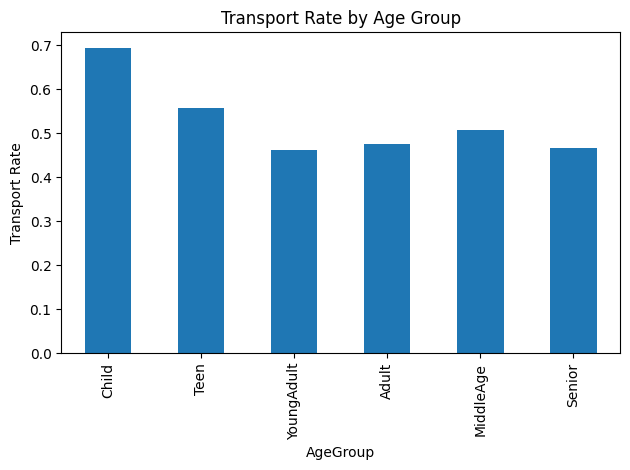

In [10]:
age_temp = train.copy()
age_temp["AgeGroup"] = pd.cut(
    age_temp["Age"],
    bins=[-np.inf, 12, 17, 25, 40, 60, np.inf],
    labels=["Child","Teen","YoungAdult","Adult","MiddleAge","Senior"]
)

age_result = (
    age_temp.groupby("AgeGroup", observed=False)[TARGET]
    .agg(["count","mean"])
    .rename(columns={"mean":"Transport_Rate"})
)
display(age_result)

age_result["Transport_Rate"].plot(kind="bar")
plt.title("Transport Rate by Age Group")
plt.ylabel("Transport Rate")
plt.tight_layout()
plt.show()

In [11]:
all_predictors = pd.concat(
    [train.drop(columns=TARGET), test],
    ignore_index=True
)

all_group_ids = all_predictors[ID].astype(str).str.split("_").str[0]
GROUP_COUNTS = all_group_ids.value_counts()

all_surnames = (
    all_predictors["Name"]
    .fillna("")
    .astype(str)
    .str.rsplit(n=1)
    .str[-1]
)
SURNAME_COUNTS = all_surnames[all_surnames != ""].value_counts()

def engineer_features(df):
    x = df.copy()

    # PassengerId -> group information
    pid = x[ID].astype(str)
    x["GroupId"] = pid.str.split("_").str[0]
    x["GroupMemberNo"] = pd.to_numeric(
        pid.str.split("_").str[1], errors="coerce"
    )
    x["GroupSize"] = x["GroupId"].map(GROUP_COUNTS)
    x["TravelingSolo"] = (x["GroupSize"] == 1).astype(int)

    # Cabin -> deck / number / side
    cabin = (
        x["Cabin"]
        .fillna("Unknown/Unknown/Unknown")
        .astype(str)
        .str.split("/", expand=True)
    )
    x["CabinDeck"] = cabin[0].replace("Unknown", np.nan)
    x["CabinNum"] = pd.to_numeric(
        cabin[1].replace("Unknown", np.nan), errors="coerce"
    )
    x["CabinSide"] = cabin[2].replace("Unknown", np.nan)

    # Spending
    spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
    x["TotalSpend"] = x[spend_cols].sum(axis=1, min_count=1)
    x["NoSpend"] = (x[spend_cols].fillna(0).sum(axis=1) == 0).astype(int)
    x["LuxurySpend"] = x[["Spa","VRDeck"]].sum(axis=1, min_count=1)
    x["EssentialSpend"] = x[["RoomService","FoodCourt","ShoppingMall"]].sum(axis=1, min_count=1)

    for col in spend_cols + ["TotalSpend","LuxurySpend","EssentialSpend"]:
        x[f"log_{col}"] = np.log1p(x[col].clip(lower=0))

    # Name -> surname / family-size proxy
    x["Surname"] = (
        x["Name"].fillna("").astype(str)
        .str.rsplit(n=1).str[-1]
        .replace("", np.nan)
    )
    x["FamilySize"] = x["Surname"].map(SURNAME_COUNTS)

    # Age bands
    x["AgeGroup"] = pd.cut(
        x["Age"],
        bins=[-np.inf, 12, 17, 25, 40, 60, np.inf],
        labels=["Child","Teen","YoungAdult","Adult","MiddleAge","Senior"]
    )

    return x.drop(
        columns=[ID, "Cabin", "Name", "GroupId", "Surname"]
    )

X = engineer_features(train.drop(columns=TARGET))
y = train[TARGET].astype(int)
X_test = engineer_features(test)

print("Engineered X:", X.shape)
display(X.head())

Engineered X: (5798, 30)


,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,...,log_RoomService,log_FoodCourt,log_ShoppingMall,log_Spa,log_VRDeck,log_TotalSpend,log_LuxurySpend,log_EssentialSpend,FamilySize,AgeGroup
0,Earth,True,PSO J318.5-22,33.0,False,0.0,0.0,0.0,0.0,NaN,...,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,4.0,Adult
1,Earth,False,TRAPPIST-1e,32.0,False,0.0,0.0,47.0,857.0,23.0,...,0.000000,0.000000,3.871201,6.754604,3.178054,6.833032,6.781058,3.871201,NaN,Adult
2,Earth,False,NaN,28.0,False,229.0,761.0,0.0,0.0,6.0,...,5.438079,6.635947,0.000000,0.000000,1.945910,6.904751,1.945910,6.898715,7.0,Adult
3,Earth,False,TRAPPIST-1e,13.0,False,406.0,0.0,52.0,0.0,387.0,...,6.008813,0.000000,3.970292,0.000000,5.961005,6.740519,5.961005,6.129050,5.0,Teen
4,Earth,False,PSO J318.5-22,15.0,False,64.0,0.0,0.0,0.0,640.0,...,4.174387,0.000000,0.000000,0.000000,6.463029,6.558198,6.463029,4.174387,7.0,Teen


In [12]:
categorical_cols = X.select_dtypes(
    include=["object","category","bool"]
).columns.tolist()

numerical_cols = [c for c in X.columns if c not in categorical_cols]

def make_preprocessor(scale_numeric=True):
    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        num_steps.append(("scaler", StandardScaler()))

    return ColumnTransformer([
        ("num", Pipeline(num_steps), numerical_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), categorical_cols)
    ])

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)

Training: (4638, 30)
Validation: (1160, 30)


In [14]:
# CatBoost handles categoricals natively; pass them as indices.
# We need to know which columns are cat BEFORE one-hot; in the Pipeline
# the preprocessor re-encodes them. Simpler: build a CatBoost pipeline
# that skips the preprocessor and feeds engineered features directly.
from catboost import CatBoostClassifier

# Identify categorical columns in X (the engineered frame, before Pipeline)
cat_feature_names = X.select_dtypes(include=["object","category","bool"]).columns.tolist()
cat_indices = [X.columns.get_loc(c) for c in cat_feature_names]

# CatBoost expects no NaN in categorical, fill with a sentinel string
def _prep_for_catboost(df):
    out = df.copy()
    for c in cat_feature_names:
        out[c] = out[c].astype("object").where(out[c].notna(), "Missing")
    return out

X_train_cb = _prep_for_catboost(X_train)
X_val_cb   = _prep_for_catboost(X_val)

models = {
    "Logistic Regression": Pipeline([
        ("prep", make_preprocessor(True)),
        ("model", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))
    ]),

    "SVM": Pipeline([
        ("prep", make_preprocessor(True)),
        ("model", SVC(kernel="rbf"))
    ]),

    "Random Forest": Pipeline([
        ("prep", make_preprocessor(False)),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "HistGradientBoosting": Pipeline([
        ("prep", make_preprocessor(False)),
        ("model", HistGradientBoostingClassifier(
            random_state=RANDOM_STATE
        ))
    ]),

    "XGBoost": Pipeline([
        ("prep", make_preprocessor(False)),
        ("model", XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
}

# CatBoost is handled separately because it expects raw categoricals
catboost_model = CatBoostClassifier(
    iterations=800,
    depth=6,
    learning_rate=0.05,
    cat_features=cat_indices,
    eval_metric="Accuracy",
    random_seed=RANDOM_STATE,
    verbose=0,
    early_stopping_rounds=50
)

print("Candidate models:")
for name in models:
    print("-", name)
print("- CatBoost (separate pipeline, uses raw categoricals)")


Candidate models:
- Logistic Regression
- SVM
- Random Forest
- HistGradientBoosting
- XGBoost


In [15]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

rows = []

# Standard sklearn pipelines
for name, model in models.items():
    print("Cross-validating:", name)

    scores = cross_validate(
        model,
        X_train, y_train,
        cv=cv,
        scoring={"accuracy":"accuracy", "f1":"f1", "roc_auc":"roc_auc"},
        n_jobs=-1
    )

    rows.append({
        "Model": name,
        "CV_Accuracy": scores["test_accuracy"].mean(),
        "CV_Accuracy_SD": scores["test_accuracy"].std(),
        "CV_F1": scores["test_f1"].mean(),
        "CV_ROC_AUC": scores["test_roc_auc"].mean()
    })

# CatBoost uses StratifiedKFold manually because of native cat handling
from sklearn.base import clone
cb_scores = {"accuracy": [], "f1": [], "roc_auc": []}
for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train_cb, y_train)):
    cb = clone(catboost_model)
    cb.fit(
        X_train_cb.iloc[tr_idx], y_train.iloc[tr_idx],
        eval_set=(X_train_cb.iloc[va_idx], y_train.iloc[va_idx]),
        verbose=0
    )
    pred = cb.predict(X_train_cb.iloc[va_idx]).astype(int)
    proba = cb.predict_proba(X_train_cb.iloc[va_idx])[:, 1]
    cb_scores["accuracy"].append(accuracy_score(y_train.iloc[va_idx], pred))
    cb_scores["f1"].append(f1_score(y_train.iloc[va_idx], pred))
    cb_scores["roc_auc"].append(roc_auc_score(y_train.iloc[va_idx], proba))
    print(f"  CatBoost fold {fold+1}: acc={cb_scores['accuracy'][-1]:.4f}")

rows.append({
    "Model": "CatBoost",
    "CV_Accuracy": np.mean(cb_scores["accuracy"]),
    "CV_Accuracy_SD": np.std(cb_scores["accuracy"]),
    "CV_F1": np.mean(cb_scores["f1"]),
    "CV_ROC_AUC": np.mean(cb_scores["roc_auc"])
})

cv_results = pd.DataFrame(rows).sort_values("CV_Accuracy", ascending=False)
display(cv_results.round(4))


Cross-validating: Logistic Regression
Cross-validating: SVM
Cross-validating: Random Forest
Cross-validating: HistGradientBoosting
Cross-validating: XGBoost


,Model,CV_Accuracy,CV_Accuracy_SD,CV_F1,CV_ROC_AUC
4,XGBoost,0.8038,0.0120,0.8062,0.8963
3,HistGradientBoosting,0.8006,0.0100,0.8012,0.8934
1,SVM,0.8004,0.0124,0.8082,0.8766
0,Logistic Regression,0.7963,0.0144,0.8030,0.8791
2,Random Forest,0.7909,0.0126,0.7906,0.8800


In [ ]:
# ================================================================
# HYPERPARAMETER TUNING — RandomizedSearchCV on top 3 models
# Uses 5-fold CV with accuracy as the scoring metric.
# Each search is bounded so it finishes in a few minutes.
# ================================================================
from scipy.stats import randint, uniform

tuning_results = {}

# ---- 1. XGBoost ----
xgb_pipe = Pipeline([
    ("prep", make_preprocessor(False)),
    ("model", XGBClassifier(
        eval_metric="logloss", tree_method="hist",
        random_state=RANDOM_STATE, n_jobs=-1
    ))
])
xgb_search = RandomizedSearchCV(
    xgb_pipe,
    param_distributions={
        "model__n_estimators": randint(200, 600),
        "model__max_depth": randint(3, 8),
        "model__learning_rate": uniform(0.01, 0.15),
        "model__subsample": uniform(0.6, 0.4),
        "model__colsample_bytree": uniform(0.6, 0.4),
        "model__min_child_weight": randint(1, 6),
        "model__reg_alpha": uniform(0, 1),
        "model__reg_lambda": uniform(0.5, 1.5),
    },
    n_iter=25, scoring="accuracy", cv=cv, n_jobs=-1,
    random_state=RANDOM_STATE, verbose=1
)
xgb_search.fit(X_train, y_train)
tuning_results["XGBoost (tuned)"] = xgb_search.best_score_
print("XGBoost best params:", xgb_search.best_params_)

# ---- 2. Random Forest ----
rf_pipe = Pipeline([
    ("prep", make_preprocessor(False)),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])
rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions={
        "model__n_estimators": randint(200, 600),
        "model__max_depth": randint(4, 16),
        "model__min_samples_split": randint(2, 20),
        "model__min_samples_leaf": randint(1, 10),
        "model__max_features": ["sqrt", "log2", None],
    },
    n_iter=25, scoring="accuracy", cv=cv, n_jobs=-1,
    random_state=RANDOM_STATE, verbose=1
)
rf_search.fit(X_train, y_train)
tuning_results["Random Forest (tuned)"] = rf_search.best_score_
print("Random Forest best params:", rf_search.best_params_)

# ---- 3. CatBoost (manual loop, CatBoost has its own search) ----
from sklearn.model_selection import train_test_split
cb_grid = []
for depth in [4, 6, 8]:
    for lr in [0.03, 0.05, 0.08]:
        Xtr, Xva, ytr, yva = train_test_split(
            X_train_cb, y_train, test_size=0.15,
            stratify=y_train, random_state=RANDOM_STATE
        )
        m = CatBoostClassifier(
            iterations=600, depth=depth, learning_rate=lr,
            cat_features=cat_indices, eval_metric="Accuracy",
            random_seed=RANDOM_STATE, verbose=0
        )
        m.fit(Xtr, ytr, eval_set=(Xva, yva), early_stopping_rounds=40, verbose=0)
        acc = accuracy_score(yva, m.predict(Xva))
        cb_grid.append({"depth": depth, "lr": lr, "val_acc": acc})
        print(f"CatBoost depth={depth} lr={lr} -> {acc:.4f}")

cb_best = max(cb_grid, key=lambda r: r["val_acc"])
print("CatBoost best:", cb_best)

# ---- Summary table ----
tuning_df = pd.DataFrame([
    {"Model": k, "Tuned_CV_Accuracy": v} for k, v in tuning_results.items()
] + [{"Model": "CatBoost (manual grid)", "Tuned_CV_Accuracy": cb_best["val_acc"]}])

tuning_df = tuning_df.sort_values("Tuned_CV_Accuracy", ascending=False)
display(tuning_df.round(4))

# Persist the tuned estimators so the submission cell can use them
TUNED = {
    "XGBoost": xgb_search.best_estimator_,
    "Random Forest": rf_search.best_estimator_,
}
CB_BEST_PARAMS = cb_best
print("\nTuning complete. Best estimators stored in TUNED / CB_BEST_PARAMS.")


In [ ]:
# Prepare CatBoost-shaped test frame
X_test_cb = _prep_for_catboost(X_test) if "X_test" in dir() else None

# ================================================================
# SUBMISSION GENERATION (uses tuned models when available)
# ================================================================
from sklearn.base import clone
import shutil

os.makedirs("/content/submissions", exist_ok=True)
os.makedirs(f"{REPO_DIR}/submissions", exist_ok=True)

# Pick top 5 from cv_results; if tuned versions beat base, swap them in.
cv_lookup = dict(zip(cv_results["Model"], cv_results["CV_Accuracy"]))
if "TUNED" in dir():
    for tuned_name, est in TUNED.items():
        # Compare tuned vs base; use tuned if it's at least as good
        base_acc = cv_lookup.get(tuned_name, 0)
        # Recompute tuned accuracy from tuning_df
        tuned_row = tuning_df[tuning_df["Model"].str.startswith(tuned_name)]
        if not tuned_row.empty and tuned_row["Tuned_CV_Accuracy"].iloc[0] >= base_acc:
            models[tuned_name] = est
            cv_lookup[tuned_name] = tuned_row["Tuned_CV_Accuracy"].iloc[0]
            print(f"Using tuned {tuned_name} (acc {tuned_row['Tuned_CV_Accuracy'].iloc[0]:.4f})")

# Top 5 by (possibly updated) CV accuracy
top5 = sorted(cv_lookup.items(), key=lambda kv: kv[1], reverse=True)[:5]
print("\nSubmitting, in order:")
for i, (m, a) in enumerate(top5, 1):
    print(f"  {i}. {m} (CV acc {a:.4f})")

for rank, (model_name, _) in enumerate(top5, 1):
    print(f"\n--- Rank {rank}: {model_name} ---")

    if model_name == "CatBoost":
        from sklearn.model_selection import train_test_split
        Xtr, Xva, ytr, yva = train_test_split(
            X_train_cb, y_train, test_size=0.1,
            stratify=y_train, random_state=RANDOM_STATE
        )
        full_cb = CatBoostClassifier(
            iterations=800,
            depth=CB_BEST_PARAMS["depth"],
            learning_rate=CB_BEST_PARAMS["lr"],
            cat_features=cat_indices, eval_metric="Accuracy",
            random_seed=RANDOM_STATE, verbose=0
        )
        full_cb.fit(Xtr, ytr, eval_set=(Xva, yva), early_stopping_rounds=50, verbose=0)
        preds = full_cb.predict(X_test_cb).astype(int)
    else:
        fitted = clone(models[model_name]).fit(X, y)
        preds = fitted.predict(X_test).astype(int)

    sub = pd.DataFrame({
        "PassengerId": test[ID].values,
        "Transported": preds.astype(bool)
    })

    out_name = f"submission_{rank}_{model_name.replace(' ','_')}.csv"
    out_local = f"/content/submissions/{out_name}"
    out_repo  = f"{REPO_DIR}/submissions/{out_name}"
    sub.to_csv(out_local, index=False)
    shutil.copy(out_local, out_repo)
    print(f"  Saved: {out_repo}  (Transported=True: {preds.sum()} / {len(preds)})")

print("\nAll 5 submissions written to /content/submissions/ and repo/submissions/.")


In [ ]:
# ================================================================
# EXPLAINABLE AI — SHAP on the best CV model + permutation importance
# Saves 2 figures into the repo so the presentation can grab them.
# ================================================================
import shap

# Pick the best CV model (already a fitted Pipeline in TUNED or models)
best_name = cv_results.iloc[0]["Model"]
print(f"Explaining best CV model: {best_name}")

# Get a fitted version of the best model on the training set
if best_name in TUNED:
    best_model = TUNED[best_name]
else:
    best_model = clone(models[best_name])
best_model.fit(X_train, y_train)

# Preprocess once for tree-based models so SHAP sees the right matrix
if best_name in ["XGBoost", "Random Forest", "HistGradientBoosting"]:
    preproc = best_model.named_steps["prep"]
    clf     = best_model.named_steps["model"]
    X_train_pp = preproc.transform(X_train)
    feature_names = preproc.get_feature_names_out()

    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_train_pp)

    # Summary plot
    plt.figure(figsize=(10, 7))
    if isinstance(shap_values, list):  # binary classification
        shap.summary_plot(shap_values[1], X_train_pp,
                          feature_names=feature_names, show=False)
    else:
        shap.summary_plot(shap_values, X_train_pp,
                          feature_names=feature_names, show=False)
    plt.title(f"SHAP Summary — {best_name}")
    plt.tight_layout()
    fig_path = f"{REPO_DIR}/notebooks/shap_summary_{best_name.replace(' ','_')}.png"
    plt.savefig(fig_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fig_path}")

# Permutation importance (model-agnostic) on the validation set
print("\nPermutation importance on validation set...")
perm = permutation_importance(
    best_model, X_val, y_val, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)
imp_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False).head(20)

display(imp_df)

# Plot
plt.figure(figsize=(9, 7))
plt.barh(imp_df["feature"][::-1], imp_df["importance_mean"][::-1],
         xerr=imp_df["importance_std"][::-1], color="steelblue")
plt.xlabel("Permutation importance (accuracy drop)")
plt.title(f"Top 20 features — {best_name}")
plt.tight_layout()
fig_path2 = f"{REPO_DIR}/notebooks/perm_importance_{best_name.replace(' ','_')}.png"
plt.savefig(fig_path2, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path2}")
